In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
from sqlalchemy import create_engine
from urllib.parse import quote_plus
from sqlalchemy import text 

In [2]:
username = "root"
password = quote_plus("YOUR_MYSQL_PASSWORD")
host = "localhost"
database = "ml_project"

engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}/{database}")

# Test the connection
with engine.connect() as conn:
    print("Connected successfully!") 

Connected successfully!


In [23]:
import os
import pandas as pd

folder = "data1"

for file in os.listdir(folder):
    if file.endswith(".csv"):
        table_name = file.replace(".csv", "")
        df = pd.read_csv(os.path.join(folder, file))
        df.to_sql(table_name, engine, if_exists = "replace", index = False)

        print(f"{table_name} uploaded successfully.") 

begin_inventory uploaded successfully.
end_inventory uploaded successfully.
purchases uploaded successfully.
purchase_prices uploaded successfully.
vendor_invoice uploaded successfully.


In [49]:
with engine.connect() as conn:
    result = conn.execute(text("SHOW TABLES"))

    for row in result:
        print(row)

('begin_inventory',)
('end_inventory',)
('purchase_prices',)
('purchases',)
('vendor_invoice',)


In [51]:
# Get all table names
tables = pd.read_sql("SHOW TABLES", engine)

# MySQL returns one column containing the table names
table_column = tables.columns[0]

for table in tables[table_column]:
    print(f"\nTable Name: {table}")
    display(pd.read_sql(f"SELECT * FROM `{table}` LIMIT 5", engine))


Table Name: begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01



Table Name: end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31



Table Name: purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.



Table Name: purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1



Table Name: vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


In [65]:
query = """
SELECT
    p.PONumber,
    COUNT(DISTINCT p.Brand) AS total_brands,
    SUM(p.Quantity) AS total_item_quantity,
    SUM(p.Dollars) AS total_item_dollars,
    AVG(DATEDIFF(p.ReceivingDate, p.PODate)) AS avg_receiving_delay
FROM purchases p
GROUP BY p.PONumber;
"""

purchase_agg_df = pd.read_sql(query, engine)
purchase_agg_df

,PONumber,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay
0,8106,81,10100.0,137483.78,12.6141
1,8107,2,24.0,348.72,12.5000
2,8108,165,8466.0,60281.13,12.6325
3,8109,23,2246.0,14298.09,12.6269
4,8110,183,8086.0,56493.23,12.6953
...,...,...,...,...,...
5538,13657,3,253.0,3844.39,4.8710
5539,13658,111,14115.0,102949.38,5.0163
5540,13659,13,338.0,2492.20,4.7353
5541,13660,12,195.0,2599.66,4.6111


In [67]:
query = """
SELECT
    vi.Quantity as invoice_quantity,
    vi.Dollars as invoice_dollars,
    vi.Freight,
    DATEDIFF(vi.InvoiceDate, vi.PODate) AS days_PO_to_invoice,
    DATEDIFF(vi.PayDate, vi.InvoiceDate) AS days_to_pay
FROM vendor_invoice vi 
"""

invoice_df  = pd.read_sql(query, engine) 
invoice_df

,invoice_quantity,invoice_dollars,Freight,days_PO_to_invoice,days_to_pay
0,6,214.26,3.47,14,43
1,15,140.55,8.57,16,45
2,5,106.60,4.61,16,38
3,10100,137483.78,2935.20,23,24
4,1935,15527.25,429.20,14,36
...,...,...,...,...,...
5538,90,1563.00,8.60,16,35
5539,4617,37300.48,186.50,18,39
5540,9848,202815.78,932.95,11,33
5541,24747,149007.56,819.54,14,36


In [71]:
query = """
SELECT
    p.PONumber,

    p.total_brands,
    p.total_item_quantity,
    p.total_item_dollars,
    p.avg_receiving_delay,

    vi.invoice_quantity,
    vi.invoice_dollars,
    vi.Freight,
    vi.days_PO_to_invoice,
    vi.days_to_pay

FROM
    (SELECT
        PONumber,
        COUNT(DISTINCT Brand) AS total_brands,
        SUM(Quantity) AS total_item_quantity,
        SUM(Dollars) AS total_item_dollars,
        AVG(DATEDIFF(ReceivingDate, PODate)) AS avg_receiving_delay
    FROM purchases
    GROUP BY PONumber
) p

LEFT JOIN

    (SELECT
        PONumber,
        Quantity AS invoice_quantity,
        Dollars AS invoice_dollars,
        Freight,
        DATEDIFF(InvoiceDate, PODate) AS days_PO_to_invoice,
        DATEDIFF(PayDate, InvoiceDate) AS days_to_pay
    FROM vendor_invoice
) vi

ON p.PONumber = vi.PONumber;
"""

df = pd.read_sql(query, engine)
df

,PONumber,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay,invoice_quantity,invoice_dollars,Freight,days_PO_to_invoice,days_to_pay
0,8106,81,10100.0,137483.78,12.6141,10100,137483.78,2935.20,23,24
1,8107,2,24.0,348.72,12.5000,24,348.72,9.08,16,36
2,8108,165,8466.0,60281.13,12.6325,8466,60281.13,1549.81,22,30
3,8109,23,2246.0,14298.09,12.6269,2246,14298.09,408.72,23,30
4,8110,183,8086.0,56493.23,12.6953,8086,56493.23,1300.92,20,41
...,...,...,...,...,...,...,...,...,...,...
5538,13655,6,301.0,2709.49,5.4074,48,1028.16,5.65,14,39
5539,13657,3,253.0,3844.39,4.8710,65,1248.61,5.74,17,41
5540,13658,111,14115.0,102949.38,5.0163,38896,502128.05,2761.70,18,40
5541,13659,13,338.0,2492.20,4.7353,195,2599.66,11.70,12,37


In [79]:
df.dtypes

PONumber                 int64
total_brands             int64
total_item_quantity    float64
total_item_dollars     float64
avg_receiving_delay    float64
invoice_quantity         int64
invoice_dollars        float64
Freight                float64
days_PO_to_invoice       int64
days_to_pay              int64
dtype: object

In [81]:
df.isnull().sum()

PONumber               0
total_brands           0
total_item_quantity    0
total_item_dollars     0
avg_receiving_delay    0
invoice_quantity       0
invoice_dollars        0
Freight                0
days_PO_to_invoice     0
days_to_pay            0
dtype: int64

In [155]:
df.describe().round()

,PONumber,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay,invoice_quantity,invoice_dollars,Freight,days_PO_to_invoice,days_to_pay,flag_invoice
count,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0
mean,10889.0,41.0,6059.0,58073.0,8.0,6059.0,58073.0,296.0,16.0,35.0,0.0
std,1601.0,77.0,14453.0,140234.0,2.0,14453.0,140234.0,714.0,3.0,6.0,0.0
min,8106.0,1.0,1.0,4.0,3.0,1.0,4.0,0.0,9.0,23.0,0.0
25%,9504.0,3.0,83.0,968.0,6.0,83.0,968.0,5.0,14.0,31.0,0.0
50%,10890.0,7.0,423.0,4765.0,8.0,423.0,4765.0,25.0,16.0,35.0,0.0
75%,12276.0,46.0,5100.0,44587.0,9.0,5100.0,44587.0,230.0,19.0,40.0,1.0
max,13661.0,807.0,141660.0,1660436.0,13.0,141660.0,1660436.0,8468.0,23.0,48.0,1.0


## creating target feature

In [187]:
def create_invoice_risk_label(row):
    # invoice total mismatches with item-level total
    if (abs(row['invoice_dollars'] - row['total_item_dollars'])) > 5:
        return 1

    # abnormally high receiving delay
    if row['avg_receiving_delay'] > 10:
        return 1

    return 0

In [189]:
df['flag_invoice'] = df.apply(create_invoice_risk_label, axis = 1)
df['flag_invoice'].value_counts()

flag_invoice
0    3693
1    1850
Name: count, dtype: int64

<Axes: xlabel='flag_invoice'>

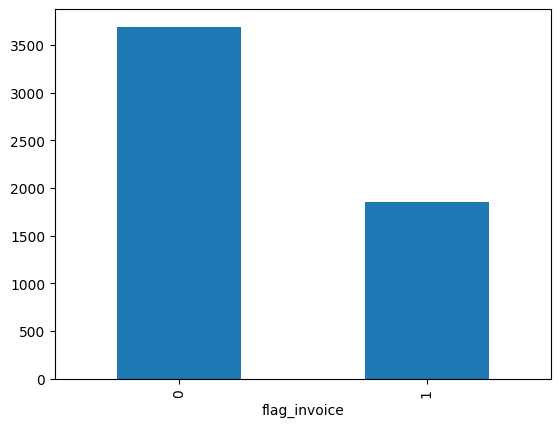

In [191]:
df['flag_invoice'].value_counts().plot(kind = 'bar')

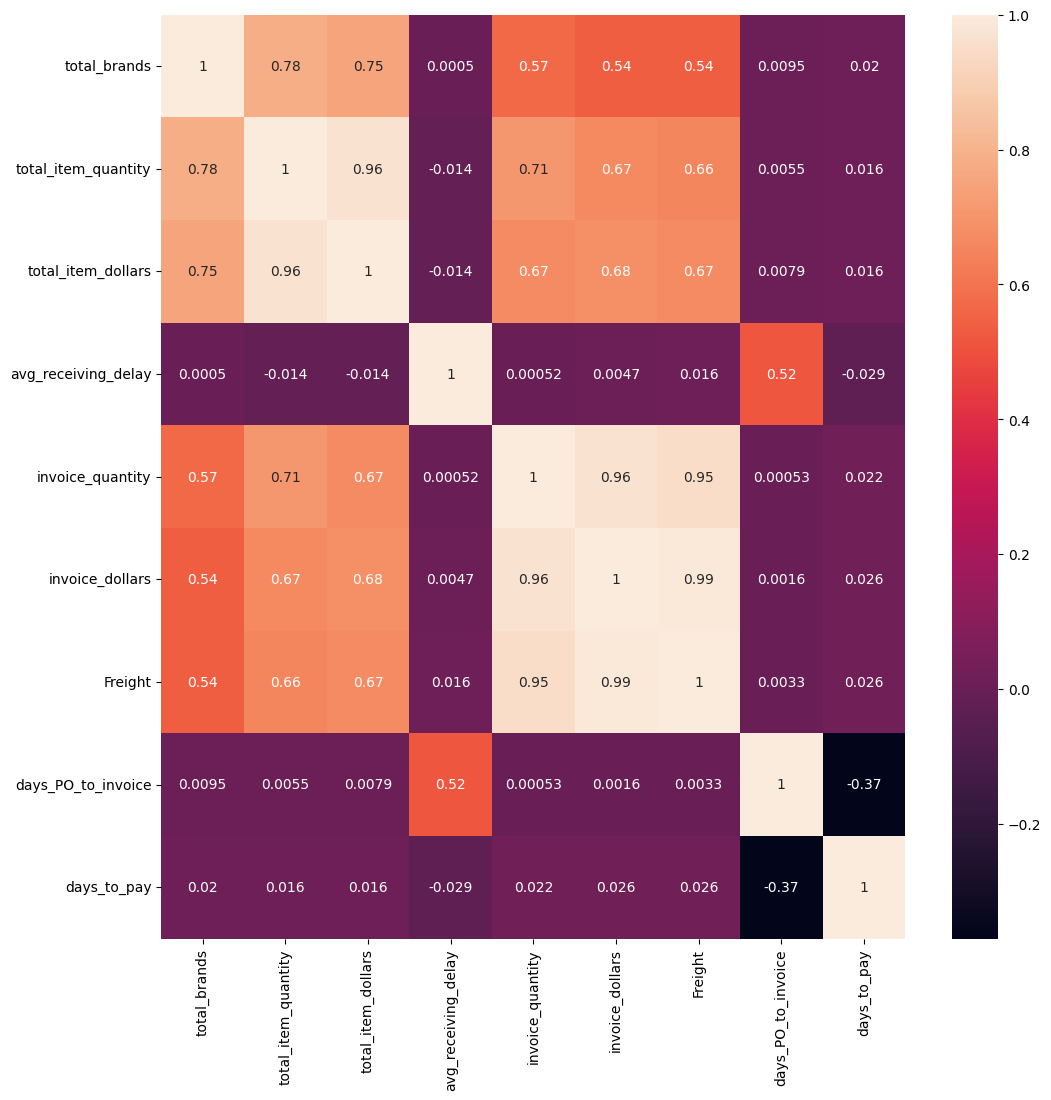

In [193]:
plt.figure(figsize = (12, 12))
sns.heatmap(df.iloc[:, 1:-1].corr(), annot = True)
plt.show()

In [195]:
flagged = df[df['flag_invoice'] == 1]
normal = df[df['flag_invoice'] == 0]

### we will perform T-test here 

In [198]:
significant_features = []
non_significant_features = []
results = []

In [200]:
metrics = ['PONumber', 'total_brands', 'total_item_quantity', 'total_item_dollars', 
           'avg_receiving_delay', 'invoice_quantity', 'invoice_dollars',	
           'Freight', 'days_PO_to_invoice', 'days_to_pay'] 

In [202]:
from scipy.stats import ttest_ind

for i in metrics:
    flagged_mean = flagged[i].mean()
    normal_mean = normal[i].mean()

    t_test, p_value = ttest_ind(flagged[i].dropna(), normal[i].dropna(), equal_var = False)

    if p_value < 0.05:
        significant_features.append(i)
        results.append({
            "metric" : i,
            "flagged_mean" : flagged_mean.round(2),
            "normal_mean" : normal_mean.round(2),
            "p_value" : p_value.round(3)
        })
    else:
        non_significant_features.append(i) 

In [204]:
non_significant_features

['total_brands', 'days_to_pay']

In [206]:
significant_features

['PONumber',
 'total_item_quantity',
 'total_item_dollars',
 'avg_receiving_delay',
 'invoice_quantity',
 'invoice_dollars',
 'Freight',
 'days_PO_to_invoice']

In [208]:
results

[{'metric': 'PONumber',
  'flagged_mean': np.float64(12167.11),
  'normal_mean': np.float64(10249.36),
  'p_value': np.float64(0.0)},
 {'metric': 'total_item_quantity',
  'flagged_mean': np.float64(6728.28),
  'normal_mean': np.float64(5723.55),
  'p_value': np.float64(0.021)},
 {'metric': 'total_item_dollars',
  'flagged_mean': np.float64(65600.61),
  'normal_mean': np.float64(54302.64),
  'p_value': np.float64(0.008)},
 {'metric': 'avg_receiving_delay',
  'flagged_mean': np.float64(8.47),
  'normal_mean': np.float64(7.27),
  'p_value': np.float64(0.0)},
 {'metric': 'invoice_quantity',
  'flagged_mean': np.float64(6728.28),
  'normal_mean': np.float64(5723.55),
  'p_value': np.float64(0.021)},
 {'metric': 'invoice_dollars',
  'flagged_mean': np.float64(65600.61),
  'normal_mean': np.float64(54302.64),
  'p_value': np.float64(0.008)},
 {'metric': 'Freight',
  'flagged_mean': np.float64(334.02),
  'normal_mean': np.float64(276.89),
  'p_value': np.float64(0.008)},
 {'metric': 'days_PO_t

In [210]:
X = df[['total_brands', 'total_item_quantity', 'total_item_dollars', 
        'invoice_quantity', 'invoice_dollars',	'Freight', 'days_PO_to_invoice']]

y = df['flag_invoice'] 

In [214]:
X.describe().round()

,total_brands,total_item_quantity,total_item_dollars,invoice_quantity,invoice_dollars,Freight,days_PO_to_invoice
count,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0
mean,41.0,6059.0,58073.0,6059.0,58073.0,296.0,16.0
std,77.0,14453.0,140234.0,14453.0,140234.0,714.0,3.0
min,1.0,1.0,4.0,1.0,4.0,0.0,9.0
25%,3.0,83.0,968.0,83.0,968.0,5.0,14.0
50%,7.0,423.0,4765.0,423.0,4765.0,25.0,16.0
75%,46.0,5100.0,44587.0,5100.0,44587.0,230.0,19.0
max,807.0,141660.0,1660436.0,141660.0,1660436.0,8468.0,23.0


In [226]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42) 

In [280]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [346]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [348]:
model1 = LogisticRegression(random_state = 42)
model1.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [350]:
model2 = DecisionTreeClassifier(random_state = 42)
model2.fit(X_train_scaled, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [352]:
model3 = RandomForestClassifier(random_state = 42)
model3.fit(X_train_scaled, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [354]:
from sklearn.metrics import classification_report 

def evaluate_model(model, X_test, y_Test, model_name):
    preds = model.predict(X_test)

    metrics = classification_report(y_test, preds) 

    print(f'\n{model_name} performance : ')
    print(f'{metrics}') 

In [356]:
evaluate_model(model1, X_test_scaled, y_test, 'Logistic Regression')
evaluate_model(model2, X_test_scaled, y_test, 'Decision Tree Classsifier')
evaluate_model(model3, X_test_scaled, y_test, 'Random Forest Classsifier')


Logistic Regression performance : 
              precision    recall  f1-score   support

           0       0.69      0.95      0.80       750
           1       0.52      0.10      0.17       359

    accuracy                           0.68      1109
   macro avg       0.61      0.53      0.49      1109
weighted avg       0.64      0.68      0.60      1109


Decision Tree Classsifier performance : 
              precision    recall  f1-score   support

           0       0.87      0.88      0.87       750
           1       0.74      0.72      0.73       359

    accuracy                           0.83      1109
   macro avg       0.80      0.80      0.80      1109
weighted avg       0.82      0.83      0.83      1109


Random Forest Classsifier performance : 
              precision    recall  f1-score   support

           0       0.86      0.97      0.91       750
           1       0.92      0.67      0.78       359

    accuracy                           0.88      1109
   macro

In [310]:
feature_importance = pd.DataFrame({
    "features" : X_train.columns,
    "importance" : model3.feature_importances_
})

feature_importance

,features,importance
0,total_brands,0.089475
1,total_item_quantity,0.178614
2,total_item_dollars,0.225541
3,invoice_quantity,0.140086
4,invoice_dollars,0.146497
5,Freight,0.143705
6,days_PO_to_invoice,0.076082


In [312]:
param_grid = {
    "n_estimators" : [100, 200, 300],
    "max_depth" : [None, 4, 5, 6],
    "min_samples_split" : [2, 3, 5],
    "min_samples_leaf" : [1, 2, 5],
    "criterion" : ["gini", "entropy"]
} 

In [320]:
from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(random_state = 42, n_jobs = -1)

scorer = make_scorer(f1_score)
grid_search = GridSearchCV(estimator = rf, 
                           param_grid = param_grid, 
                           scoring = scorer, 
                           cv = 5, 
                           verbose = 2, 
                           n_jobs = -1)

grid_search.fit(X_train_scaled, y_train)
evaluate_model(grid_search, X_test_scaled, y_test, 'Random Forest Classsifier') 

Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Random Forest Classsifier performance : 
              precision    recall  f1-score   support

           0       0.86      0.97      0.92       750
           1       0.92      0.68      0.79       359

    accuracy                           0.88      1109
   macro avg       0.89      0.83      0.85      1109
weighted avg       0.88      0.88      0.87      1109



In [322]:
from sklearn.metrics import confusion_matrix

confusion_matrix(grid_search.predict(X_test_scaled), y_test)

array([[730, 114],
       [ 20, 245]])

In [324]:
confusion_matrix(model3.predict(X_test_scaled), y_test)

array([[729, 117],
       [ 21, 242]])

In [326]:
grid_search.best_params_

{'criterion': 'gini',
 'max_depth': None,
 'min_samples_leaf': 1,
 'min_samples_split': 5,
 'n_estimators': 200}